In [5]:
import sys
import os

import torch
from dataclasses import dataclass, field
from abc import ABC, abstractmethod
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
from typing import Any, NamedTuple

sys.path.append(os.path.expanduser("~")+"/dev/MLStudy/mllib")

import rllib

# Running

In [6]:
envname = 'LunarLander-v2'
env = gym.make(envname, render_mode="rgb_array")

In [7]:
N = 48
class NeuralNetwork(nn.Module):
    def __init__(self, obs_size, act_size):
        super().__init__()
        self.affine = nn.Linear(obs_size, N)
        self.hidden = nn.Linear(N,N)
        self.affine2 = nn.Linear(obs_size, N)
        self.hidden2 = nn.Linear(N,N)
        self.action_head = nn.Linear(N, act_size)
        self.value_head = nn.Linear(N, 1)

    def forward(self, x):
        x1 = F.relu(self.affine(x))
        x1 = F.relu(self.hidden(x1))
        x2 = F.relu(self.affine2(x))
        x2 = F.relu(self.hidden2(x2))
        prob = self.action_head(x1)
        value = self.value_head(x2)

        return prob, value

    def get_policy(self, observation):
        logits = self.forward(observation)[0]
        return torch.distributions.Categorical(logits=logits)

    def get_value(self, observation):
        return self.forward(observation)[1]


In [8]:
model = NeuralNetwork(env.observation_space.shape[0], env.action_space.n)
model.load_state_dict(torch.load("lander5.model"))
agent = rllib.A2CMLAgent(model, env.observation_space.shape[0], False)
rllib.run_jupyter(envname, agent, 10240)

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

# Training

In [ ]:
model_sizes = [32,48,64,80,96]
eps = [0.1,0.2,0.3,0.4]
bs = [16,32,48,128]
gs = [0.9,0.95, 0.99, 0.995]
lrs = [1e-5, 1e-4, 1e-3, 1e-2]
res = []
for random_seed in [32114124, 12354423, 2524353, 2566237, 697345]:
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(random_seed)
    
    model = NeuralNetwork(env.observation_space.shape[0], env.action_space.n)
    agent = rllib.A2CMLAgent(model, env.observation_space.shape[0], False)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    options = rllib.PPOOptions(optimizer)
    options.gamma = 0.99
    options.epsilon = 0.1
    options.batch_size = 16
    options.epochs = 2000
    options.entropy = 0.01
    options.num_envs = 1
    options.max_episode_len = 10240
    options.report_reward = lambda x: print(x)
    stats = rllib.ppo_train(envname, agent, options)
    res.append((stats,agent))

In [70]:
rllib.run_jupyter(envname, agent, 10240)

KeyboardInterrupt: 

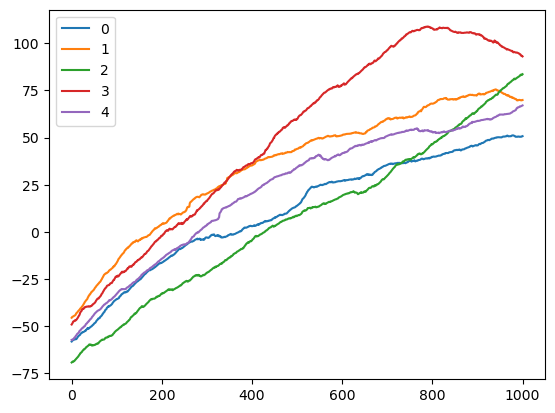

In [51]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size):
    weights = np.repeat(1.0, window_size) / window_size
    smoothed = np.convolve(data, weights, 'valid')
    return smoothed

# Assuming res is a list of (x, y) pairs
window_size = 100
for i in range(len(res)):
    smoothed_y = moving_average(res[i][0].reward_history, window_size)
    plt.plot(smoothed_y, label=str(i))

plt.legend()
plt.show()

In [72]:
mymodel = res[0][3]

In [80]:
rh,lh,llh,model = taxi.train(envname, discrete=False, N=48, g=0.999, lr=0.001, epsilon=0.3, batch_size=128, buf_size=1024, epoch=3000, entropy=0.01, num_envs=1, loaded=model)

80.93387467718823
62.79168134365696
103.11554996808046
76.97507988888907
40.9064184408692
11.624025278286538
87.46962153272068
125.16855515676767
127.06774724066814
39.13885169069903
70.66936421907444
77.74895757123107
51.12997621941703
43.296580483607954
92.2913043510302
82.71566285805365
91.48833650054836
63.24921279627736
68.74726643998092
86.36885561855627
78.16655063996274
90.29261133351596
76.65843529295822
75.18284388461335
-102.97316816648932
27.40989461213242
100.25598709361037
29.14232670709032
69.34221805390779
111.883750884818
83.019192360868
148.67080333283886
127.09544926182068
113.478873834312
69.39055844754004
24.367878766160246
103.96726118643554
98.69725912939998
32.19478833178371
44.180298849820076
135.5619282507784
146.63666330009676
162.55798343413474
87.61439729045354
65.60620786633073
51.364151424182324
68.90190336151676
4.348864508067194
109.65825054713461
12.914929167369252
89.33094821659921
-104.72987507611063
95.12346638506118
10.644901995556936
51.1293867907

In [56]:
torch.save(res[3][1].model.state_dict(), "lander3.model")

In [57]:
mymodel = res[2][1].model

In [67]:
agent = rllib.A2CMLAgent(mymodel, env.observation_space.shape[0], False)
optimizer = torch.optim.Adam(mymodel.parameters(), lr=0.0005)
options = rllib.PPOOptions(optimizer)
options.gamma = 0.99
options.epsilon = 0.01
options.batch_size = 16
options.epochs = 1000
options.entropy = 0.00
options.num_envs = 1
options.max_episode_len = 10240
options.report_reward = lambda x: print(x)
stats = rllib.ppo_train(envname, agent, options)


283.78098081003907
269.6563050516263
287.3350718667723
267.67340006056406
286.56454968192287
272.5490407688212
41.862888050823585
306.16591752733495
217.03479629381292
246.79243093802148
255.31815090839902
286.36704116787394
275.6162230585312
-133.77856665880725
314.2684341947414
264.9302905513554
273.2901913403879
288.45555208067344
313.2035814953124
268.6389246316507
274.1097721898252
281.50294683286376
285.35768491681256
240.73596415903853
278.1923833450867
290.26046926549924
205.7536957754101
270.3485733845725
-94.19994039093797
284.87590177551215
262.52040666552
281.6103340857477
287.5519977255796
274.15333243827513
87.8634707174036
254.76274019284088
293.69977426794156
276.2052675809632
275.9786743680191
266.3412789415319
267.54726531849127
281.9228293978291
257.21628299961276
287.6809913443947
248.27421247579912
272.5699348224055
273.97230039087685
291.8874529374635
278.3549650017295
-118.12033379981666
268.6852428958363
266.7783724871984
66.99901959596468
263.26964373675594
259

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


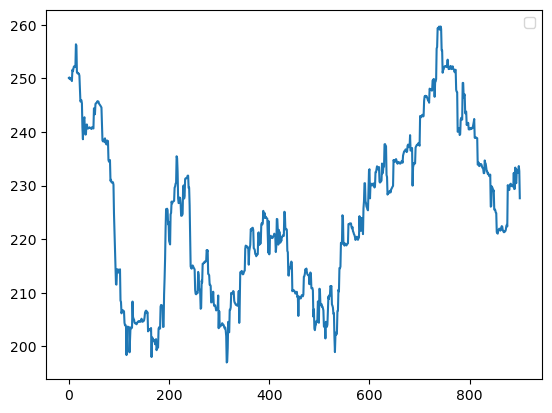

In [68]:
window_size = 100
smoothed_y = moving_average(stats.reward_history, window_size)
plt.plot(smoothed_y)

plt.legend()
plt.show()


In [71]:
torch.save(mymodel.state_dict(), "lander5.model")
